# Comparação de Conjuntos - Lotofácil

Análise comparativa entre um conjunto de números escolhido e o resultado de um sorteio específico.

## 1. Importar Bibliotecas Necessárias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 2. Definir Conjuntos para Comparação

In [2]:
# Conjunto de referência (sua aposta)
conjunto_aposta = {1, 2, 3, 4, 5, 6, 16, 18, 19, 20, 21, 22, 23, 24, 25}

# Resultado do sorteio
conjunto_sorteio = {1, 2, 4, 8, 9, 10, 13, 16, 17, 19, 20, 21, 22, 23, 25}

print("=" * 80)
print("CONJUNTOS DEFINIDOS")
print("=" * 80)
print(f"\n📋 Conjunto Aposta:  {sorted(conjunto_aposta)}")
print(f"🎯 Resultado Sorteio: {sorted(conjunto_sorteio)}")
print(f"\nTotal de números em cada conjunto: 15")

CONJUNTOS DEFINIDOS

📋 Conjunto Aposta:  [1, 2, 3, 4, 5, 6, 16, 18, 19, 20, 21, 22, 23, 24, 25]
🎯 Resultado Sorteio: [1, 2, 4, 8, 9, 10, 13, 16, 17, 19, 20, 21, 22, 23, 25]

Total de números em cada conjunto: 15


## 3. Análise de Diferenças entre Conjuntos

In [3]:
# Números em comum (acertos)
acertos = conjunto_aposta & conjunto_sorteio

# Números na aposta que NÃO saíram no sorteio
nao_acertados = conjunto_aposta - conjunto_sorteio

# Números no sorteio que NÃO estavam na aposta
nao_apostados = conjunto_sorteio - conjunto_aposta

print("=" * 80)
print("ANÁLISE DETALHADA")
print("=" * 80)

print(f"\n✅ ACERTOS ({len(acertos)} números):")
print(f"   {sorted(acertos)}")

print(f"\n❌ NA APOSTA mas NÃO SAÍRAM ({len(nao_acertados)} números):")
print(f"   {sorted(nao_acertados)}")

print(f"\n⚠️  SAÍRAM mas NÃO APOSTADOS ({len(nao_apostados)} números):")
print(f"   {sorted(nao_apostados)}")

print(f"\n{'='*80}")
print(f"ESTATÍSTICAS")
print(f"{'='*80}")
print(f"Taxa de acerto: {len(acertos)}/15 = {len(acertos)/15*100:.2f}%")
print(f"Números a trocar: {len(nao_acertados)} (remover da aposta)")
print(f"Números faltantes: {len(nao_apostados)} (adicionar à aposta)")

ANÁLISE DETALHADA

✅ ACERTOS (10 números):
   [1, 2, 4, 16, 19, 20, 21, 22, 23, 25]

❌ NA APOSTA mas NÃO SAÍRAM (5 números):
   [3, 5, 6, 18, 24]

⚠️  SAÍRAM mas NÃO APOSTADOS (5 números):
   [8, 9, 10, 13, 17]

ESTATÍSTICAS
Taxa de acerto: 10/15 = 66.67%
Números a trocar: 5 (remover da aposta)
Números faltantes: 5 (adicionar à aposta)


## 4. Análise das Substituições Necessárias

In [5]:
# Criar DataFrame com as substituições necessárias
max_len = max(len(nao_acertados), len(nao_apostados))

substituicoes = {
    'Remover da Aposta': sorted(nao_acertados) + [''] * (max_len - len(nao_acertados)),
    'Adicionar à Aposta': sorted(nao_apostados) + [''] * (max_len - len(nao_apostados))
}

df_substituicoes = pd.DataFrame(substituicoes)

print("=" * 80)
print("SUBSTITUIÇÕES NECESSÁRIAS PARA ACERTAR 15 NÚMEROS")
print("=" * 80)
print(df_substituicoes.to_string(index=False))

print(f"\n💡 Para transformar a aposta no resultado vencedor:")
print(f"   • Remova: {sorted(nao_acertados)}")
print(f"   • Adicione: {sorted(nao_apostados)}")

SUBSTITUIÇÕES NECESSÁRIAS PARA ACERTAR 15 NÚMEROS
 Remover da Aposta  Adicionar à Aposta
                 3                   8
                 5                   9
                 6                  10
                18                  13
                24                  17

💡 Para transformar a aposta no resultado vencedor:
   • Remova: [3, 5, 6, 18, 24]
   • Adicione: [8, 9, 10, 13, 17]


## 5. Visualização Gráfica das Diferenças

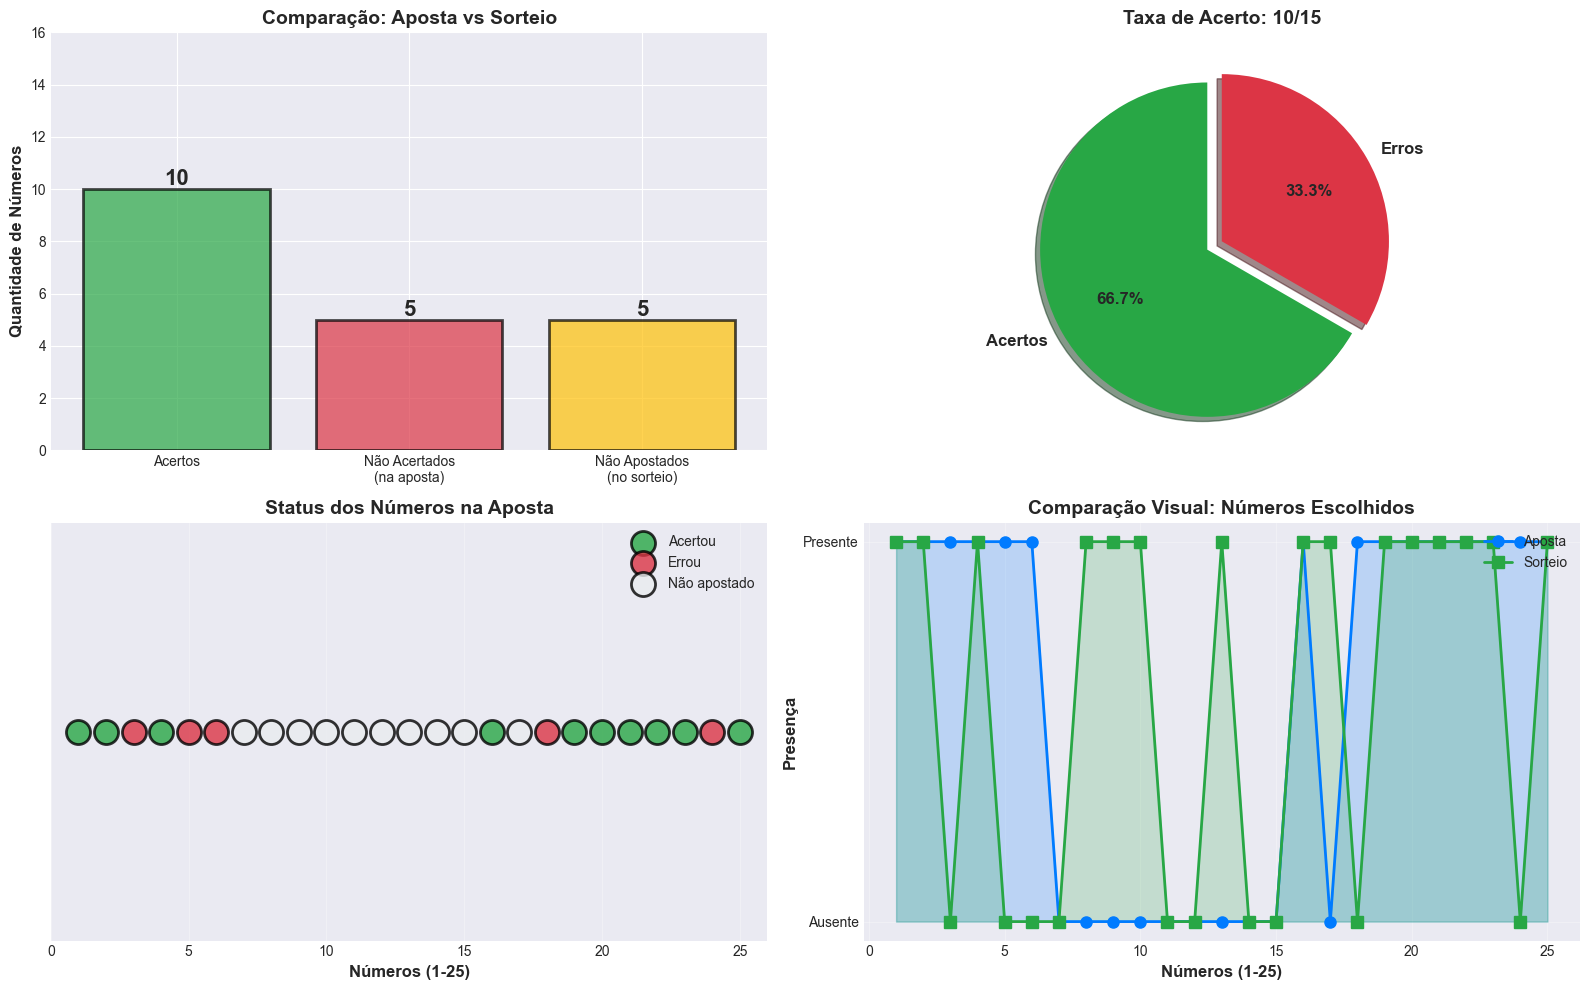


✅ Visualizações geradas com sucesso!


In [6]:
# Criar visualização comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Gráfico 1: Comparação de conjuntos
ax1 = axes[0, 0]
categorias = ['Acertos', 'Não Acertados\n(na aposta)', 'Não Apostados\n(no sorteio)']
valores = [len(acertos), len(nao_acertados), len(nao_apostados)]
cores = ['#28a745', '#dc3545', '#ffc107']

bars = ax1.bar(categorias, valores, color=cores, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Quantidade de Números', fontsize=12, fontweight='bold')
ax1.set_title('Comparação: Aposta vs Sorteio', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 16)

# Adicionar valores nas barras
for bar, valor in zip(bars, valores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{valor}',
             ha='center', va='bottom', fontsize=16, fontweight='bold')

# Gráfico 2: Taxa de acerto
ax2 = axes[0, 1]
labels = ['Acertos', 'Erros']
sizes = [len(acertos), len(nao_acertados)]
colors_pie = ['#28a745', '#dc3545']
explode = (0.1, 0)

wedges, texts, autotexts = ax2.pie(sizes, explode=explode, labels=labels, colors=colors_pie,
                                     autopct='%1.1f%%', shadow=True, startangle=90,
                                     textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title(f'Taxa de Acerto: {len(acertos)}/15', fontsize=14, fontweight='bold')

# Gráfico 3: Números na aposta (acertos vs erros)
ax3 = axes[1, 0]
todos_aposta = list(range(1, 26))
status = []
for num in todos_aposta:
    if num in acertos:
        status.append('Acertou')
    elif num in nao_acertados:
        status.append('Errou')
    else:
        status.append('Não apostado')

colors_scatter = {'Acertou': '#28a745', 'Errou': '#dc3545', 'Não apostado': '#e9ecef'}
for stat in ['Acertou', 'Errou', 'Não apostado']:
    nums = [i for i, s in enumerate(todos_aposta, 1) if status[i-1] == stat]
    ax3.scatter(nums, [1]*len(nums), c=colors_scatter[stat], s=300, alpha=0.8, 
                label=stat, edgecolors='black', linewidth=2)

ax3.set_xlabel('Números (1-25)', fontsize=12, fontweight='bold')
ax3.set_title('Status dos Números na Aposta', fontsize=14, fontweight='bold')
ax3.set_xlim(0, 26)
ax3.set_ylim(0.5, 1.5)
ax3.set_yticks([])
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, axis='x', alpha=0.3)

# Gráfico 4: Timeline de números
ax4 = axes[1, 1]
numeros_ordenados = list(range(1, 26))
y_aposta = []
y_sorteio = []

for num in numeros_ordenados:
    y_aposta.append(1 if num in conjunto_aposta else 0)
    y_sorteio.append(1 if num in conjunto_sorteio else 0)

ax4.plot(numeros_ordenados, y_aposta, 'o-', label='Aposta', linewidth=2, 
         markersize=8, color='#007bff')
ax4.plot(numeros_ordenados, y_sorteio, 's-', label='Sorteio', linewidth=2, 
         markersize=8, color='#28a745')
ax4.fill_between(numeros_ordenados, y_aposta, alpha=0.2, color='#007bff')
ax4.fill_between(numeros_ordenados, y_sorteio, alpha=0.2, color='#28a745')

ax4.set_xlabel('Números (1-25)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Presença', fontsize=12, fontweight='bold')
ax4.set_title('Comparação Visual: Números Escolhidos', fontsize=14, fontweight='bold')
ax4.set_yticks([0, 1])
ax4.set_yticklabels(['Ausente', 'Presente'])
ax4.legend(loc='upper right', fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualizações geradas com sucesso!")

## 6. Análise Adicional: Padrões e Características

In [7]:
# Análise de características dos conjuntos
def analisar_conjunto(conjunto, nome):
    """Analisa características de um conjunto de números"""
    nums = sorted(list(conjunto))
    
    # Paridade
    pares = sum(1 for n in nums if n % 2 == 0)
    impares = len(nums) - pares
    
    # Soma
    soma_total = sum(nums)
    
    # Consecutivos
    consecutivos = 0
    for i in range(len(nums) - 1):
        if nums[i+1] - nums[i] == 1:
            consecutivos += 1
    
    # Primos
    primos = {2, 3, 5, 7, 11, 13, 17, 19, 23}
    qtd_primos = len(set(nums) & primos)
    
    # Faixas: Baixos (1-8), Médios (9-17), Altos (18-25)
    baixos = sum(1 for n in nums if 1 <= n <= 8)
    medios = sum(1 for n in nums if 9 <= n <= 17)
    altos = sum(1 for n in nums if 18 <= n <= 25)
    
    print(f"\n{'='*80}")
    print(f"CARACTERÍSTICAS: {nome}")
    print(f"{'='*80}")
    print(f"Números: {nums}")
    print(f"\n📊 Paridade:")
    print(f"   Pares: {pares} | Ímpares: {impares}")
    print(f"\n➕ Soma Total: {soma_total}")
    print(f"\n🔢 Consecutivos: {consecutivos} pares")
    print(f"\n🔺 Números Primos: {qtd_primos}")
    print(f"\n📈 Distribuição por Faixas:")
    print(f"   Baixos (1-8): {baixos}")
    print(f"   Médios (9-17): {medios}")
    print(f"   Altos (18-25): {altos}")
    
    return {
        'pares': pares,
        'impares': impares,
        'soma': soma_total,
        'consecutivos': consecutivos,
        'primos': qtd_primos,
        'baixos': baixos,
        'medios': medios,
        'altos': altos
    }

stats_aposta = analisar_conjunto(conjunto_aposta, "APOSTA")
stats_sorteio = analisar_conjunto(conjunto_sorteio, "SORTEIO")


CARACTERÍSTICAS: APOSTA
Números: [1, 2, 3, 4, 5, 6, 16, 18, 19, 20, 21, 22, 23, 24, 25]

📊 Paridade:
   Pares: 8 | Ímpares: 7

➕ Soma Total: 209

🔢 Consecutivos: 12 pares

🔺 Números Primos: 5

📈 Distribuição por Faixas:
   Baixos (1-8): 6
   Médios (9-17): 1
   Altos (18-25): 8

CARACTERÍSTICAS: SORTEIO
Números: [1, 2, 4, 8, 9, 10, 13, 16, 17, 19, 20, 21, 22, 23, 25]

📊 Paridade:
   Pares: 7 | Ímpares: 8

➕ Soma Total: 210

🔢 Consecutivos: 8 pares

🔺 Números Primos: 5

📈 Distribuição por Faixas:
   Baixos (1-8): 4
   Médios (9-17): 5
   Altos (18-25): 6


## 7. Comparação de Características

In [8]:
# Comparar características lado a lado
print("\n" + "="*80)
print("COMPARAÇÃO DE CARACTERÍSTICAS")
print("="*80)

df_comparacao = pd.DataFrame({
    'Característica': ['Pares', 'Ímpares', 'Soma Total', 'Consecutivos', 
                       'Primos', 'Baixos (1-8)', 'Médios (9-17)', 'Altos (18-25)'],
    'Aposta': [
        stats_aposta['pares'],
        stats_aposta['impares'],
        stats_aposta['soma'],
        stats_aposta['consecutivos'],
        stats_aposta['primos'],
        stats_aposta['baixos'],
        stats_aposta['medios'],
        stats_aposta['altos']
    ],
    'Sorteio': [
        stats_sorteio['pares'],
        stats_sorteio['impares'],
        stats_sorteio['soma'],
        stats_sorteio['consecutivos'],
        stats_sorteio['primos'],
        stats_sorteio['baixos'],
        stats_sorteio['medios'],
        stats_sorteio['altos']
    ]
})

df_comparacao['Diferença'] = df_comparacao['Sorteio'] - df_comparacao['Aposta']

print("\n" + df_comparacao.to_string(index=False))

# Destacar maiores diferenças
print(f"\n{'='*80}")
print("MAIORES DIFERENÇAS:")
print(f"{'='*80}")
df_diff = df_comparacao[df_comparacao['Diferença'] != 0].copy()
df_diff = df_diff.sort_values('Diferença', key=abs, ascending=False)

for _, row in df_diff.iterrows():
    sinal = "+" if row['Diferença'] > 0 else ""
    print(f"  • {row['Característica']}: {sinal}{row['Diferença']}")


COMPARAÇÃO DE CARACTERÍSTICAS

Característica  Aposta  Sorteio  Diferença
         Pares       8        7         -1
       Ímpares       7        8          1
    Soma Total     209      210          1
  Consecutivos      12        8         -4
        Primos       5        5          0
  Baixos (1-8)       6        4         -2
 Médios (9-17)       1        5          4
 Altos (18-25)       8        6         -2

MAIORES DIFERENÇAS:
  • Consecutivos: -4
  • Médios (9-17): +4
  • Baixos (1-8): -2
  • Altos (18-25): -2
  • Soma Total: +1
  • Pares: -1
  • Ímpares: +1


## 8. Gerar Conjuntos com 7 Números Diferentes e Soma 206

Criar 10 combinações baseadas no conjunto de referência, onde cada combinação deve ter:
- **8 números em comum** com o conjunto base
- **7 números diferentes** do conjunto base
- **Soma total = 206**

In [9]:
from itertools import combinations

# Conjunto base de referência
conjunto_base = {2, 3, 4, 5, 9, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25}
soma_objetivo = 206

print("=" * 80)
print("CONFIGURAÇÃO DA BUSCA")
print("=" * 80)
print(f"Conjunto base: {sorted(conjunto_base)}")
print(f"Soma do conjunto base: {sum(conjunto_base)}")
print(f"Soma objetivo: {soma_objetivo}")
print(f"\nRequisitos:")
print(f"  • Manter 8 números do conjunto base")
print(f"  • Substituir 7 números por outros de 1-25")
print(f"  • Soma total = {soma_objetivo}")

CONFIGURAÇÃO DA BUSCA
Conjunto base: [2, 3, 4, 5, 9, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25]
Soma do conjunto base: 224
Soma objetivo: 206

Requisitos:
  • Manter 8 números do conjunto base
  • Substituir 7 números por outros de 1-25
  • Soma total = 206


In [10]:
# Função para gerar combinações válidas
def gerar_combinacoes_7_diferentes(conjunto_base, soma_alvo, quantidade=10):
    """
    Gera combinações de 15 números onde:
    - 8 números são do conjunto_base
    - 7 números são diferentes (de 1-25 excluindo o conjunto_base)
    - Soma total = soma_alvo
    """
    todos_numeros = set(range(1, 26))
    numeros_disponiveis = todos_numeros - conjunto_base
    
    resultados = []
    tentativas = 0
    max_tentativas = 100000
    
    print(f"\n{'='*80}")
    print("BUSCANDO COMBINAÇÕES...")
    print(f"{'='*80}")
    print(f"Números disponíveis para substituição: {sorted(numeros_disponiveis)}")
    print(f"Quantidade de números disponíveis: {len(numeros_disponiveis)}")
    
    # Testar combinações de 8 números do conjunto base
    for combo_manter in combinations(sorted(conjunto_base), 8):
        tentativas += 1
        if tentativas > max_tentativas:
            break
            
        soma_mantidos = sum(combo_manter)
        soma_necessaria = soma_alvo - soma_mantidos
        
        # Agora precisamos de 7 números dos disponíveis que somem soma_necessaria
        for combo_novos in combinations(sorted(numeros_disponiveis), 7):
            if sum(combo_novos) == soma_necessaria:
                conjunto_final = set(combo_manter) | set(combo_novos)
                
                # Verificar se já temos essa combinação
                if conjunto_final not in [r['conjunto'] for r in resultados]:
                    resultados.append({
                        'conjunto': conjunto_final,
                        'lista': sorted(conjunto_final),
                        'mantidos': sorted(combo_manter),
                        'novos': sorted(combo_novos),
                        'soma': sum(conjunto_final),
                        'qtd_comum': len(conjunto_final & conjunto_base)
                    })
                    
                    print(f"✓ Encontrada {len(resultados)}/{quantidade}")
                    
                    if len(resultados) >= quantidade:
                        return resultados
    
    return resultados

# Buscar 10 combinações
print("Iniciando busca...")
combinacoes = gerar_combinacoes_7_diferentes(conjunto_base, soma_objetivo, quantidade=10)

print(f"\n{'='*80}")
print(f"✅ BUSCA CONCLUÍDA: {len(combinacoes)} combinações encontradas")
print(f"{'='*80}")

Iniciando busca...

BUSCANDO COMBINAÇÕES...
Números disponíveis para substituição: [1, 6, 7, 8, 10, 11, 12, 13, 14, 19]
Quantidade de números disponíveis: 10
✓ Encontrada 1/10
✓ Encontrada 2/10
✓ Encontrada 3/10
✓ Encontrada 4/10
✓ Encontrada 5/10
✓ Encontrada 6/10
✓ Encontrada 7/10
✓ Encontrada 8/10
✓ Encontrada 9/10
✓ Encontrada 10/10

✅ BUSCA CONCLUÍDA: 10 combinações encontradas


In [11]:
# Exibir resultados detalhados
print("\n" + "=" * 80)
print("LISTA DE 10 CONJUNTOS COM 7 NÚMEROS DIFERENTES E SOMA 206")
print("=" * 80)

for i, comb in enumerate(combinacoes, 1):
    print(f"\n{i}. CONJUNTO:")
    print(f"   Números: {comb['lista']}")
    print(f"   Soma: {comb['soma']}")
    print(f"   Em comum com base: {comb['qtd_comum']} números")
    print(f"   Mantidos: {comb['mantidos']}")
    print(f"   Novos: {comb['novos']}")
    print(f"   {'-'*76}")


LISTA DE 10 CONJUNTOS COM 7 NÚMEROS DIFERENTES E SOMA 206

1. CONJUNTO:
   Números: [2, 3, 4, 8, 10, 11, 12, 13, 14, 16, 19, 22, 23, 24, 25]
   Soma: 206
   Em comum com base: 8 números
   Mantidos: [2, 3, 4, 16, 22, 23, 24, 25]
   Novos: [8, 10, 11, 12, 13, 14, 19]
   ----------------------------------------------------------------------------

2. CONJUNTO:
   Números: [2, 3, 4, 8, 10, 11, 12, 13, 14, 17, 19, 21, 23, 24, 25]
   Soma: 206
   Em comum com base: 8 números
   Mantidos: [2, 3, 4, 17, 21, 23, 24, 25]
   Novos: [8, 10, 11, 12, 13, 14, 19]
   ----------------------------------------------------------------------------

3. CONJUNTO:
   Números: [2, 3, 4, 7, 10, 11, 12, 13, 14, 17, 19, 22, 23, 24, 25]
   Soma: 206
   Em comum com base: 8 números
   Mantidos: [2, 3, 4, 17, 22, 23, 24, 25]
   Novos: [7, 10, 11, 12, 13, 14, 19]
   ----------------------------------------------------------------------------

4. CONJUNTO:
   Números: [2, 3, 4, 8, 10, 11, 12, 13, 14, 18, 19, 20, 23,

In [ ]:
# Criar DataFrame para melhor visualização
df_resultados = pd.DataFrame({
    'Conjunto': ['-'.join([f'{n:02d}' for n in comb['lista']]) for comb in combinacoes],
    'Soma': [comb['soma'] for comb in combinacoes],
    'Comuns': [comb['qtd_comum'] for comb in combinacoes],
    'Mantidos': [','.join(map(str, comb['mantidos'])) for comb in combinacoes],
    'Novos': [','.join(map(str, comb['novos'])) for comb in combinacoes]
})

print("\n" + "=" * 80)
print("TABELA RESUMIDA")
print("=" * 80)
print(df_resultados.to_string(index=False))

# Exportar para CSV
from pathlib import Path
arquivo_saida = Path('data') / 'conjuntos_7_diferentes_soma_206.csv'
arquivo_saida.parent.mkdir(exist_ok=True)

df_resultados.to_csv(arquivo_saida, index=False, encoding='utf-8-sig')
print(f"\n✅ Resultados exportados para: {arquivo_saida}")

### Análise de Características dos Conjuntos Gerados

In [ ]:
# Analisar características de cada conjunto gerado
print("=" * 80)
print("ANÁLISE DE CARACTERÍSTICAS DOS CONJUNTOS GERADOS")
print("=" * 80)

for i, comb in enumerate(combinacoes, 1):
    numeros = comb['lista']
    
    # Paridade
    pares = sum(1 for n in numeros if n % 2 == 0)
    impares = 15 - pares
    
    # Primos
    primos = {2, 3, 5, 7, 11, 13, 17, 19, 23}
    qtd_primos = len(set(numeros) & primos)
    
    # Consecutivos
    consecutivos = 0
    for j in range(len(numeros) - 1):
        if numeros[j+1] - numeros[j] == 1:
            consecutivos += 1
    
    # Faixas
    baixos = sum(1 for n in numeros if 1 <= n <= 8)
    medios = sum(1 for n in numeros if 9 <= n <= 17)
    altos = sum(1 for n in numeros if 18 <= n <= 25)
    
    print(f"\nConjunto {i}:")
    print(f"  Pares/Ímpares: {pares}/{impares} | Primos: {qtd_primos} | Consecutivos: {consecutivos}")
    print(f"  Faixas B-M-A: {baixos}-{medios}-{altos}")

# Criar DataFrame com todas as características
df_analise = []
for i, comb in enumerate(combinacoes, 1):
    numeros = comb['lista']
    pares = sum(1 for n in numeros if n % 2 == 0)
    impares = 15 - pares
    primos_set = {2, 3, 5, 7, 11, 13, 17, 19, 23}
    qtd_primos = len(set(numeros) & primos_set)
    
    consecutivos = sum(1 for j in range(len(numeros) - 1) if numeros[j+1] - numeros[j] == 1)
    
    baixos = sum(1 for n in numeros if 1 <= n <= 8)
    medios = sum(1 for n in numeros if 9 <= n <= 17)
    altos = sum(1 for n in numeros if 18 <= n <= 25)
    
    df_analise.append({
        'Conjunto': i,
        'Pares': pares,
        'Ímpares': impares,
        'Primos': qtd_primos,
        'Consecutivos': consecutivos,
        'Baixos': baixos,
        'Médios': medios,
        'Altos': altos
    })

df_carac = pd.DataFrame(df_analise)

print(f"\n{'='*80}")
print("TABELA DE CARACTERÍSTICAS")
print(f"{'='*80}")
print(df_carac.to_string(index=False))

In [ ]:
# Visualização das características
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Gráfico 1: Distribuição de Paridade
ax1 = axes[0, 0]
df_carac.plot(x='Conjunto', y=['Pares', 'Ímpares'], kind='bar', ax=ax1, 
              color=['#007bff', '#28a745'], alpha=0.7)
ax1.set_title('Distribuição de Paridade por Conjunto', fontsize=14, fontweight='bold')
ax1.set_ylabel('Quantidade', fontsize=12)
ax1.set_xlabel('Conjunto', fontsize=12)
ax1.legend(title='Tipo')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Números Primos e Consecutivos
ax2 = axes[0, 1]
x_pos = np.arange(len(df_carac))
width = 0.35
ax2.bar(x_pos - width/2, df_carac['Primos'], width, label='Primos', 
        color='#dc3545', alpha=0.7)
ax2.bar(x_pos + width/2, df_carac['Consecutivos'], width, label='Consecutivos', 
        color='#ffc107', alpha=0.7)
ax2.set_title('Primos vs Consecutivos', fontsize=14, fontweight='bold')
ax2.set_ylabel('Quantidade', fontsize=12)
ax2.set_xlabel('Conjunto', fontsize=12)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(df_carac['Conjunto'])
ax2.legend()
ax2.grid(True, alpha=0.3)

# Gráfico 3: Distribuição por Faixas (Empilhado)
ax3 = axes[1, 0]
df_carac.plot(x='Conjunto', y=['Baixos', 'Médios', 'Altos'], kind='bar', 
              stacked=True, ax=ax3, color=['#17a2b8', '#6610f2', '#fd7e14'], alpha=0.7)
ax3.set_title('Distribuição por Faixas (B-M-A)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Quantidade', fontsize=12)
ax3.set_xlabel('Conjunto', fontsize=12)
ax3.legend(title='Faixa', labels=['Baixos (1-8)', 'Médios (9-17)', 'Altos (18-25)'])
ax3.axhline(y=15, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax3.grid(True, alpha=0.3)

# Gráfico 4: Heatmap de características
ax4 = axes[1, 1]
dados_heatmap = df_carac[['Pares', 'Ímpares', 'Primos', 'Consecutivos', 
                           'Baixos', 'Médios', 'Altos']].T
sns.heatmap(dados_heatmap, annot=True, fmt='d', cmap='YlOrRd', ax=ax4, 
            cbar_kws={'label': 'Quantidade'}, linewidths=0.5)
ax4.set_title('Heatmap de Características', fontsize=14, fontweight='bold')
ax4.set_xlabel('Conjunto', fontsize=12)
ax4.set_ylabel('Característica', fontsize=12)
ax4.set_xticklabels(range(1, len(combinacoes) + 1))

plt.tight_layout()
plt.show()

print("\n✅ Visualizações das características geradas!")